
# AI / Machine Learning / Deep Learning for Drug Response Prediction


 使用**模擬的 gene expression / multi-omics data**，帶你完成一個簡化版的：

**Molecular features → Biomarker selection → Machine Learning → Drug response prediction**

### 今天會做什麼？
1. 建立模擬的癌症 gene expression data
2. 看懂 feature 與 label
3. Filter / Wrapper / Embedded Feature Selection
4. Logistic Regression / LDA
5. KNN / Decision Tree / SVM
6. Random Forest
7. 比較所有模型
8. Neural Network（Deep Learning）
9. Autoencoder 的基本概念
10. Multi-omics：Early fusion / Late fusion
11. Cell line → Patient domain shift 的簡單示範

> **教學重點：先看圖，再理解模型。**


In [ ]:

# ============================================================
# 0. Import packages
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.feature_selection import SelectKBest, f_classif, SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier

np.random.seed(42)

print("Packages imported successfully!")


Packages imported successfully!



# 1. Create simulated gene-expression data

假設我們有：

- **300 位癌症樣本**
- **60 個 genes**
- 每位病人有一個 drug response：
  - `0 = Resistant`
  - `1 = Sensitive`

其中只有少數 genes 真正與 drug response 有關，其餘大部分是 noise。

這很像真實 omics data：

> 很多 feature，但真正有預測能力的 biomarker 只有一部分。


In [ ]:

# ============================================================
# 1. Simulated gene-expression dataset
# ============================================================

X, y = make_classification(
    n_samples=300,
    n_features=60,
    n_informative=8,       # 真正有用的 genes
    n_redundant=4,         # 與有用 genes 高度相關
    n_repeated=0,
    n_classes=2,
    class_sep=1.3,
    flip_y=0.05,
    random_state=42
)

gene_names = [f"Gene_{i+1:02d}" for i in range(X.shape[1])]

df = pd.DataFrame(X, columns=gene_names)
df["Drug_Response"] = y

print("Dataset shape:", df.shape)
print()
print(df.head())

print("\nDrug response counts:")
print(df["Drug_Response"].value_counts())


Dataset shape: (300, 61)

    Gene_01   Gene_02   Gene_03   Gene_04   Gene_05   Gene_06   Gene_07  \
0 -0.418223 -0.601294  0.861974  1.047761 -0.049596  1.194829  2.869774   
1 -1.082462  0.005800 -0.027760  0.138866 -0.163162 -0.648572  2.884081   
2  0.992590 -0.480816  0.526946  1.595347  1.036816  1.450783 -0.273339   
3  0.131515  1.407085  0.612800  0.362425 -1.143484  0.276165 -1.922595   
4 -2.039507  0.314409  0.929369 -0.306270  1.182272 -1.059324  2.624565   

    Gene_08   Gene_09   Gene_10  ...   Gene_52   Gene_53   Gene_54   Gene_55  \
0 -1.254325 -1.680005 -1.408465  ...  0.470790  0.417296  0.200262  0.504781   
1 -0.548819  0.088833  1.470482  ... -0.777857 -0.673824 -0.132598 -1.073338   
2  1.659372  0.151484 -0.791229  ... -0.929370 -0.359407 -0.917525 -0.192254   
3  0.212823 -0.219444 -0.820705  ... -1.765823 -0.343124  0.177977 -0.857068   
4 -1.145864 -0.294327 -1.714251  ... -0.461055 -2.537672 -0.860653 -0.438531   

    Gene_56   Gene_57   Gene_58   Gene_59 

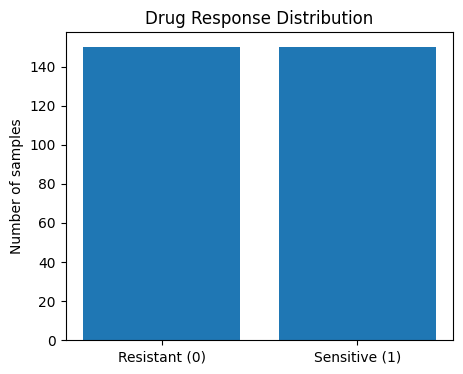

In [ ]:

# Visualize class distribution

counts = df["Drug_Response"].value_counts().sort_index()

plt.figure(figsize=(5,4))
plt.bar(["Resistant (0)", "Sensitive (1)"], counts.values)
plt.ylabel("Number of samples")
plt.title("Drug Response Distribution")
plt.show()



# 2. Train / Test split

我們不能用全部資料訓練後，再用同一批資料評估。

因此先切成：

- **Training set：80%** → 模型學習
- **Test set：20%** → 最後考試

這是 Machine Learning 最重要的基本觀念之一。


In [ ]:

X = df[gene_names]
y = df["Drug_Response"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


Training samples: 240
Testing samples : 60



# 3. Before modeling: what does a biomarker look like?

先找一個與 response 關係較大的 gene，直接把兩群畫出來。

如果某個 gene 在 Sensitive 與 Resistant 之間分布差很多，
它就可能是一個有用的 biomarker。


/tmp/ipykernel_945/2108279988.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


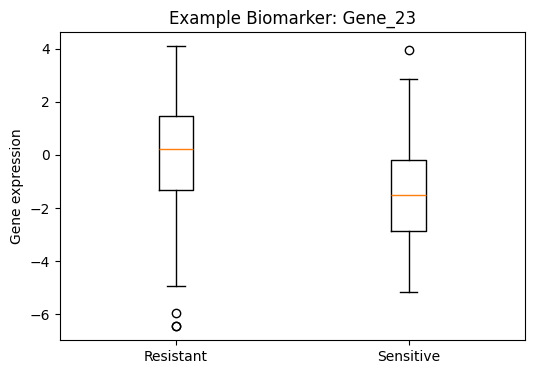

Example gene: Gene_23


In [ ]:

# Calculate mean difference between the two classes
mean_diff = (
    X_train[y_train == 1].mean() -
    X_train[y_train == 0].mean()
).abs().sort_values(ascending=False)

example_gene = mean_diff.index[0]

plt.figure(figsize=(6,4))
plt.boxplot(
    [
        X_train.loc[y_train == 0, example_gene],
        X_train.loc[y_train == 1, example_gene]
    ],
    labels=["Resistant", "Sensitive"]
)
plt.ylabel("Gene expression")
plt.title(f"Example Biomarker: {example_gene}")
plt.show()

print("Example gene:", example_gene)



# 4. Feature Selection

在 omics data 中常常有上千、上萬個 features。

Feature Selection 的目的是：

> **從很多 genes 中找出較重要的 biomarkers。**

簡報中可分成三類：

| 類型 | 核心概念 |
|---|---|
| Filter | 每個 feature 自己先考試 |
| Wrapper | 用模型測試 feature 組合 |
| Embedded | 模型訓練時順便做 feature selection |



## 4.1 Filter Method — t-test

最直觀的作法：

對每個 gene 比較：

**Sensitive vs Resistant**

如果兩群差異很大，p-value 就會比較小。



In [ ]:

# ============================================================
# Filter method: t-test
# ============================================================

results = []

for gene in gene_names:
    group0 = X_train.loc[y_train == 0, gene]
    group1 = X_train.loc[y_train == 1, gene]

    t_stat, p_value = ttest_ind(group0, group1)
    results.append([gene, t_stat, p_value])

ttest_df = pd.DataFrame(
    results,
    columns=["Gene", "t-statistic", "p-value"]
).sort_values("p-value")

print("Top 10 genes by t-test:")
print(ttest_df.head(10))


Top 10 genes by t-test:
       Gene  t-statistic       p-value
22  Gene_23     5.571429  6.815768e-08
6   Gene_07    -4.821118  2.546772e-06
45  Gene_46     4.701302  4.378990e-06
19  Gene_20     3.766442  2.087530e-04
26  Gene_27    -3.402883  7.821587e-04
7   Gene_08     2.934638  3.666036e-03
41  Gene_42    -2.685115  7.760502e-03
25  Gene_26    -2.344172  1.989270e-02
50  Gene_51     2.276555  2.370155e-02
9   Gene_10     1.996205  4.705111e-02


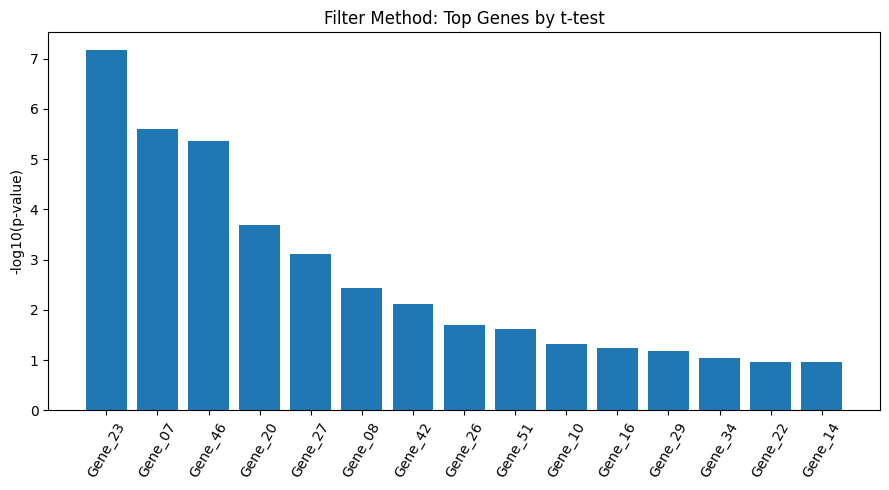

In [ ]:

# Plot top 15 genes using -log10(p-value)
plot_df = ttest_df.head(15).copy()
plot_df["-log10(p-value)"] = -np.log10(plot_df["p-value"] + 1e-300)

plt.figure(figsize=(9,5))
plt.bar(plot_df["Gene"], plot_df["-log10(p-value)"])
plt.xticks(rotation=60)
plt.ylabel("-log10(p-value)")
plt.title("Filter Method: Top Genes by t-test")
plt.tight_layout()
plt.show()



## 4.2 Filter Method — Correlation

另一個常見的 Drug Response 指標是 IC50，它不是分類標籤，而是連續數值。

Gene expression 越高，Drug IC50 是否也會跟著增加或降低？

Correlation：

接近 +1 → 正相關
接近 −1 → 負相關
接近 0 → 幾乎沒有線性相關


In [ ]:

# ============================================================
# Filter Method: Correlation
# Gene Expression vs Continuous Drug Response (IC50)
# ============================================================

np.random.seed(42)

n_samples = 100

# 模擬 IC50：連續型 Drug Response
IC50 = np.random.normal(5, 1.5, n_samples)

# 模擬 5 個 genes
correlation_df = pd.DataFrame({

    # expression 越高，IC50 越高
    "Gene_A": IC50 + np.random.normal(0, 1, n_samples),

    # expression 越高，IC50 越低
    "Gene_B": -IC50 + np.random.normal(0, 1, n_samples),

    # 較弱的正相關
    "Gene_C": 0.4 * IC50 + np.random.normal(0, 1.5, n_samples),

    # 幾乎沒有相關
    "Gene_D": np.random.normal(0, 2, n_samples),

    # 幾乎沒有相關
    "Gene_E": np.random.normal(0, 2, n_samples),

    "IC50": IC50
})

print(correlation_df.head())


     Gene_A    Gene_B    Gene_C    Gene_D    Gene_E      IC50
0  4.329700 -5.387284  1.054536 -3.188855  1.852355  5.745071
1  4.371958 -4.231819  1.076770 -1.198750  3.818833  4.792604
2  5.628818 -4.888482  3.509554  0.010487 -2.797135  5.971533
3  6.482268 -6.230743  3.829373  0.093961  1.125938  7.284545
4  4.487484 -6.026439  1.828156 -0.900131 -1.301285  4.648770


In [ ]:
genes = ["Gene_A", "Gene_B", "Gene_C", "Gene_D", "Gene_E"]

correlations = correlation_df[genes].corrwith(
    correlation_df["IC50"]
)

print("Correlation with IC50:")
print(correlations.sort_values(ascending=False))

Correlation with IC50:
Gene_A    0.793574
Gene_C    0.237253
Gene_D   -0.136187
Gene_E   -0.152475
Gene_B   -0.735470
dtype: float64


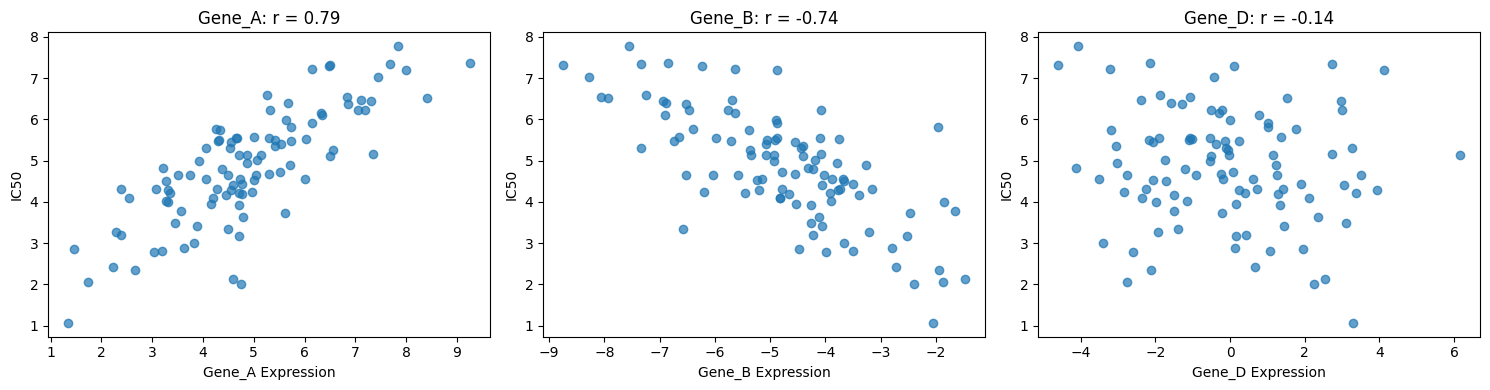

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, gene in zip(
    axes,
    ["Gene_A", "Gene_B", "Gene_D"]
):

    r = correlations[gene]

    ax.scatter(
        correlation_df[gene],
        correlation_df["IC50"],
        alpha=0.7
    )

    ax.set_xlabel(f"{gene} Expression")
    ax.set_ylabel("IC50")
    ax.set_title(f"{gene}: r = {r:.2f}")

plt.tight_layout()
plt.show()


## 4.3 Wrapper Method — Sequential Feature Selection

Wrapper 的想法不是單獨看 gene。

它會問：

> 「哪一組 genes 放進模型之後，預測最好？」

這裡使用簡單的 **Sequential Feature Selection**：
每次加入一個有幫助的 feature。


In [ ]:
# ============================================================
# Wrapper Method: Sequential Forward Selection
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

selected_genes = []
remaining_genes = gene_names.copy()

auc_history = []
gene_history = []

# Sequential Forward Selection
# 一步一步選 10 個 genes
for step in range(10):

    best_gene = None
    best_auc = -1

    # 嘗試每一個還沒被選到的 gene
    for gene in remaining_genes:

        test_genes = selected_genes + [gene]

        model = LogisticRegression(max_iter=2000)

        auc = cross_val_score(
            model,
            X_train[test_genes],
            y_train,
            cv=3,
            scoring="roc_auc"
        ).mean()

        # 找到這一輪表現最好的 gene
        if auc > best_auc:
            best_auc = auc
            best_gene = gene

    # 把最佳 gene 加入
    selected_genes.append(best_gene)
    remaining_genes.remove(best_gene)

    auc_history.append(best_auc)
    gene_history.append(best_gene)

    print(
        f"Step {step+1}: "
        f"Add {best_gene} → "
        f"AUC = {best_auc:.3f}"
    )

print("\nFinal selected genes:")
print(selected_genes)

Step 1: Add Gene_23 → AUC = 0.720
Step 2: Add Gene_07 → AUC = 0.804
Step 3: Add Gene_20 → AUC = 0.825
Step 4: Add Gene_46 → AUC = 0.834
Step 5: Add Gene_08 → AUC = 0.849
Step 6: Add Gene_42 → AUC = 0.854
Step 7: Add Gene_38 → AUC = 0.856
Step 8: Add Gene_32 → AUC = 0.863
Step 9: Add Gene_40 → AUC = 0.866
Step 10: Add Gene_60 → AUC = 0.867

Final selected genes:
['Gene_23', 'Gene_07', 'Gene_20', 'Gene_46', 'Gene_08', 'Gene_42', 'Gene_38', 'Gene_32', 'Gene_40', 'Gene_60']


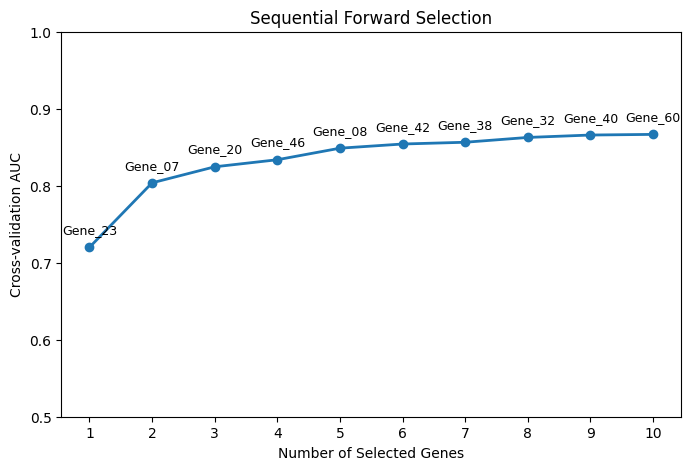

In [ ]:
plt.figure(figsize=(8, 5))

x = range(1, len(auc_history) + 1)

plt.plot(
    x,
    auc_history,
    marker="o",
    linewidth=2
)

plt.xticks(x)

plt.xlabel("Number of Selected Genes")
plt.ylabel("Cross-validation AUC")
plt.title("Sequential Forward Selection")

plt.ylim(0.5, 1.0)

# 標出每一步加入哪個 gene
for i, gene in enumerate(gene_history):

    plt.annotate(
        gene,
        (x[i], auc_history[i]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

plt.show()


## 4.4 Embedded Method — LASSO
Embedded method：

> **模型一邊訓練，一邊決定哪些 features 重要。**

LASSO 會把一些不重要 features 的 coefficient 壓到 `0`。

因此：

- coefficient ≠ 0 → 保留
- coefficient = 0 → 移除


In [ ]:

lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l1",  # 讓 LASSO 可以將部分 coefficients 壓到 0
        solver="liblinear",
        C=0.15,
        max_iter=2000
    ))
])

lasso_model.fit(X_train, y_train)

coef = lasso_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Gene": gene_names,
    "Coefficient": coef
})

coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("AbsCoefficient", ascending=False)

selected_lasso = coef_df.loc[coef_df["Coefficient"] != 0, "Gene"].tolist()

print("Number of selected genes:", len(selected_lasso))
print("Selected genes:")
print(selected_lasso)


Number of selected genes: 21
Selected genes:
['Gene_23', 'Gene_07', 'Gene_20', 'Gene_46', 'Gene_08', 'Gene_42', 'Gene_14', 'Gene_16', 'Gene_32', 'Gene_26', 'Gene_31', 'Gene_34', 'Gene_30', 'Gene_27', 'Gene_19', 'Gene_53', 'Gene_48', 'Gene_38', 'Gene_49', 'Gene_29', 'Gene_10']


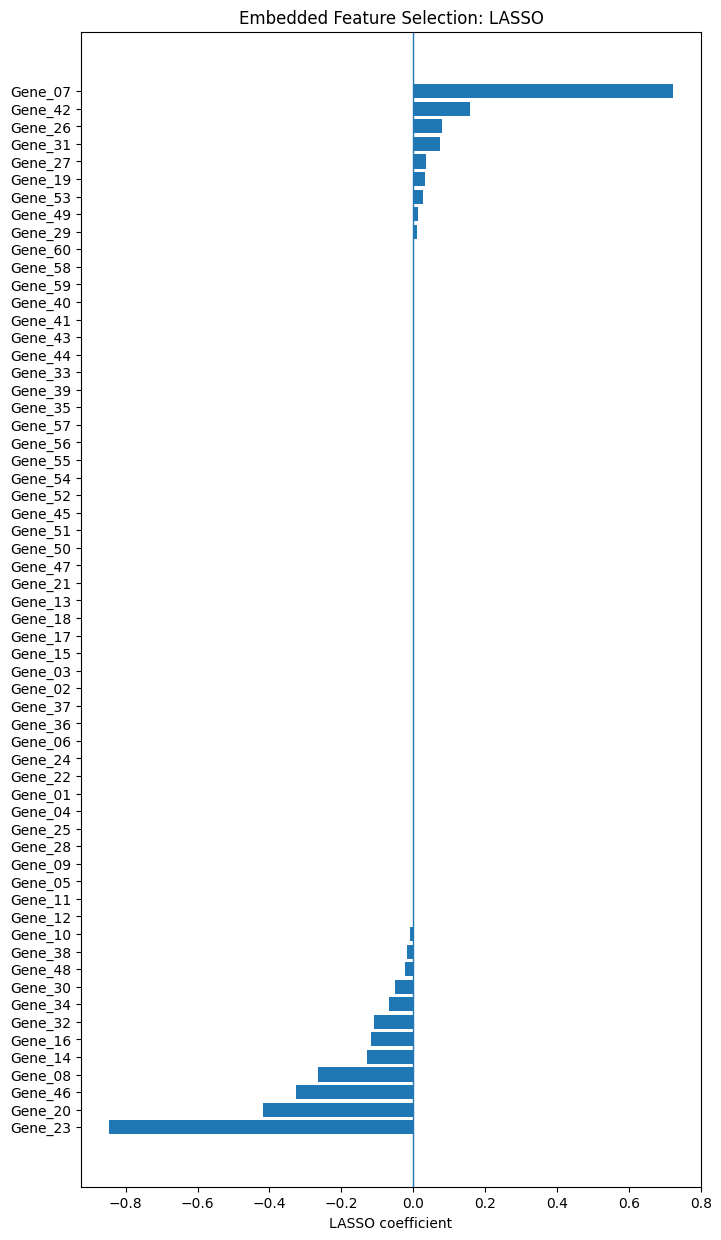

In [ ]:

plot_coef = coef_df.sort_values("Coefficient")

plt.figure(figsize=(8,15))
plt.barh(plot_coef["Gene"], plot_coef["Coefficient"])
plt.axvline(0, linewidth=1)
plt.xlabel("LASSO coefficient")
plt.title("Embedded Feature Selection: LASSO")
plt.show()



# 5. Machine Learning Classifiers

接下來固定使用相同 train/test data，比較不同 classifier。

所有模型都回答同一個問題：

> **根據 gene expression，這個樣本是 Sensitive 還是 Resistant？**

但不同模型畫「decision boundary」的方法不同。


In [ ]:
# Helper function: train, predict, print metrics, and draw figures

model_results = []

def evaluate_model(name, model, X_train, X_test, y_train, y_test):

    # =========================
    # 1. Train model
    # =========================
    model.fit(X_train, y_train)

    # =========================
    # 2. Prediction
    # =========================

    # Training set prediction
    train_pred = model.predict(X_train)

    # Testing set prediction
    test_pred = model.predict(X_test)

    # Prediction probability
    if hasattr(model, "predict_proba"):

        train_prob = model.predict_proba(X_train)[:, 1]
        test_prob = model.predict_proba(X_test)[:, 1]

    else:

        train_score = model.decision_function(X_train)
        test_score = model.decision_function(X_test)

        train_prob = (
            (train_score - train_score.min()) /
            (train_score.max() - train_score.min() + 1e-9)
        )

        test_prob = (
            (test_score - test_score.min()) /
            (test_score.max() - test_score.min() + 1e-9)
        )

    # =========================
    # 3. Performance
    # =========================

    Train_acc = accuracy_score(y_train, train_pred)
    Train_auc = roc_auc_score(y_train, train_prob)

    Test_acc = accuracy_score(y_test, test_pred)
    Test_auc = roc_auc_score(y_test, test_prob)

    print("=" * 60)
    print(name)

    print(f"Train Accuracy = {Train_acc:.3f}")
    print(f"Train AUC      = {Train_auc:.3f}")

    print()

    print(f"Test Accuracy  = {Test_acc:.3f}")
    print(f"Test AUC       = {Test_auc:.3f}")

    # =========================
    # 4. Confusion Matrix
    # =========================

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        test_pred,
        display_labels=["Resistant", "Sensitive"]
    )

    plt.title(f"{name} - Test Confusion Matrix")
    plt.show()

    # =========================
    # 5. ROC Curve
    # =========================

    fpr, tpr, _ = roc_curve(y_test, test_prob)

    plt.figure(figsize=(5, 4))

    plt.plot(
        fpr,
        tpr,
        label=f"Test AUC = {Test_auc:.3f}"
    )

    plt.plot([0, 1], [0, 1], "--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} - Test ROC Curve")

    plt.legend()
    plt.show()

    # =========================
    # 6. Save results
    # =========================

    model_results.append([
        name,
        Train_acc,
        Train_auc,
        Test_acc,
        Test_auc
    ])

    return model



## 5.1 Logistic Regression

### 一句話理解

> 把多個 features 加權後，轉成 **0～1 的 probability**。

例如：

- `P(Sensitive) = 0.85` → 預測 Sensitive
- `P(Sensitive) = 0.20` → 預測 Resistant

它是一個 **Linear Model**。


Logistic Regression
Train Accuracy = 0.871
Train AUC      = 0.928

Test Accuracy  = 0.700
Test AUC       = 0.720


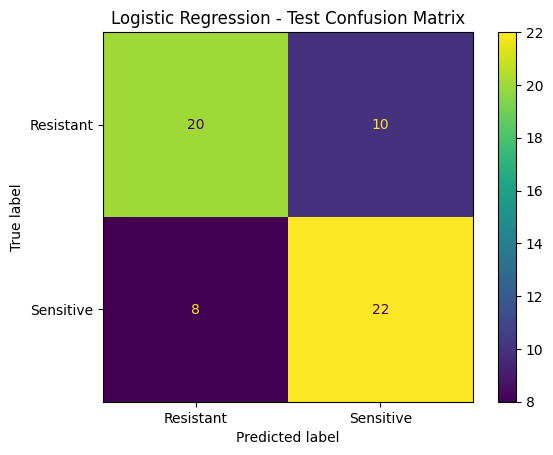

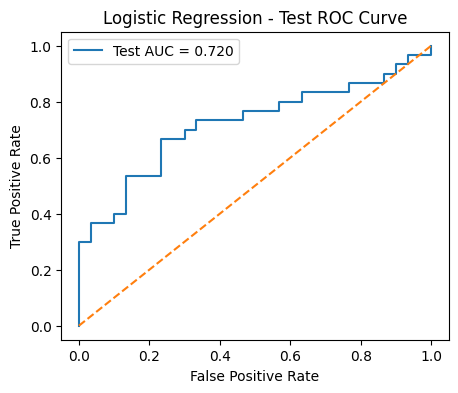

In [ ]:

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

lr = evaluate_model(
    "Logistic Regression",
    lr,
    X_train, X_test, y_train, y_test
)


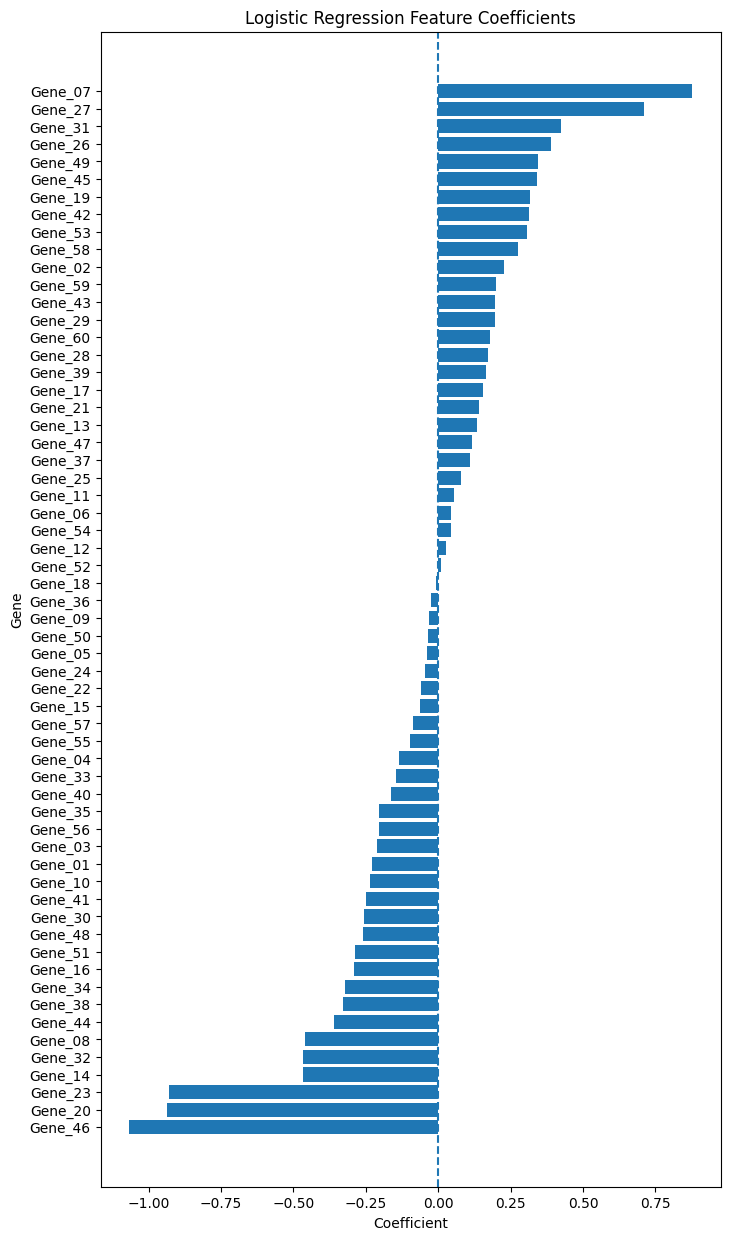

In [ ]:
# Get coefficients from the trained Logistic Regression model
lr_coef = lr.named_steps["model"].coef_[0]

lr_coef_df = pd.DataFrame({
    "Gene": gene_names,
    "Coefficient": lr_coef
})

# Sort by coefficient for visualization
lr_coef_df = lr_coef_df.sort_values("Coefficient")

plt.figure(figsize=(8, 15))

plt.barh(
    lr_coef_df["Gene"],
    lr_coef_df["Coefficient"]
)

plt.axvline(0, linestyle="--")

plt.xlabel("Coefficient")
plt.ylabel("Gene")
plt.title("Logistic Regression Feature Coefficients")

plt.show()


## 5.2 Linear Discriminant Analysis (LDA)

### 一句話理解

> 找一個方向，讓兩群投影後「盡量分開」。

LDA 關心的是：

- **Between-class variance**：兩群中心越遠越好
- **Within-class variance**：同一群內越集中越好


LDA
Train Accuracy = 0.863
Train AUC      = 0.923

Test Accuracy  = 0.667
Test AUC       = 0.707


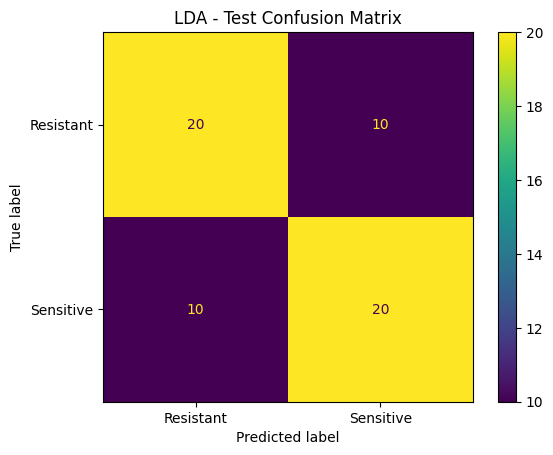

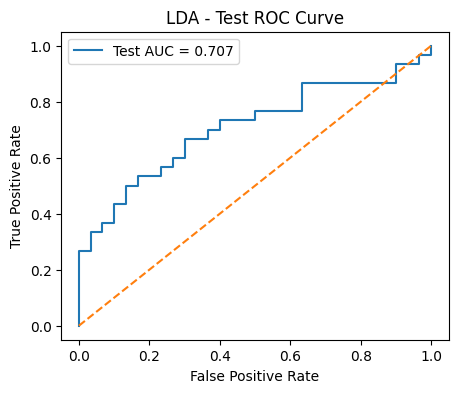

In [ ]:

lda = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearDiscriminantAnalysis())
])

lda = evaluate_model(
    "LDA",
    lda,
    X_train, X_test, y_train, y_test
)



## 5.3 K-Nearest Neighbors (KNN)

### 一句話理解

> **看附近的人是誰。**

假設 `K=5`：

新病人附近的 5 個病人中：

- 4 個 Sensitive
- 1 個 Resistant

→ 預測 Sensitive。

KNN 很直觀，但 feature 很多時容易受到距離問題影響。


KNN
Train Accuracy = 0.867
Train AUC      = 0.942

Test Accuracy  = 0.633
Test AUC       = 0.723


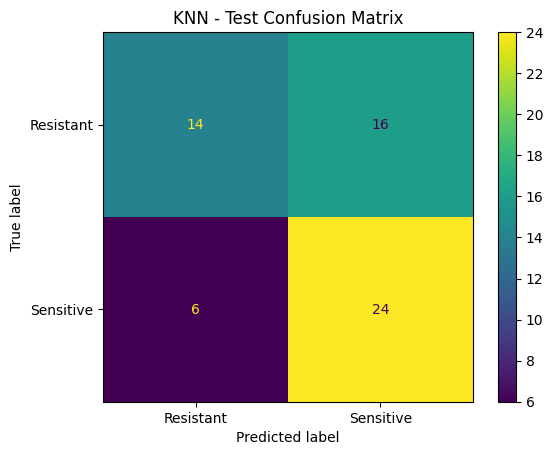

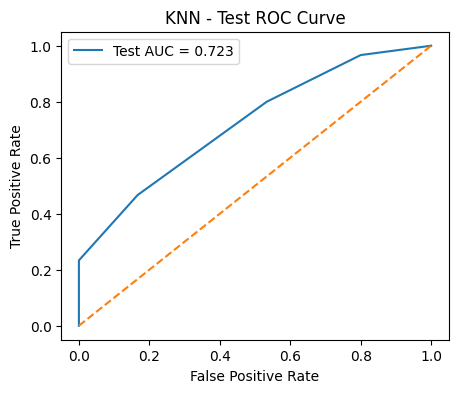

In [ ]:

knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn = evaluate_model(
    "KNN",
    knn,
    X_train, X_test, y_train, y_test
)



## 5.4 Decision Tree

### 一句話理解

> 像醫師問診一樣，一題一題往下判斷。

例如：

```text
Gene_A > 1.2 ?
    ├── Yes → Gene_B > 0.4 ?
    │            ├── Yes → Sensitive
    │            └── No  → Resistant
    └── No → Resistant
```

優點是很好解釋，但單棵 tree 容易 overfitting。


Decision Tree
Train Accuracy = 0.883
Train AUC      = 0.935

Test Accuracy  = 0.817
Test AUC       = 0.818


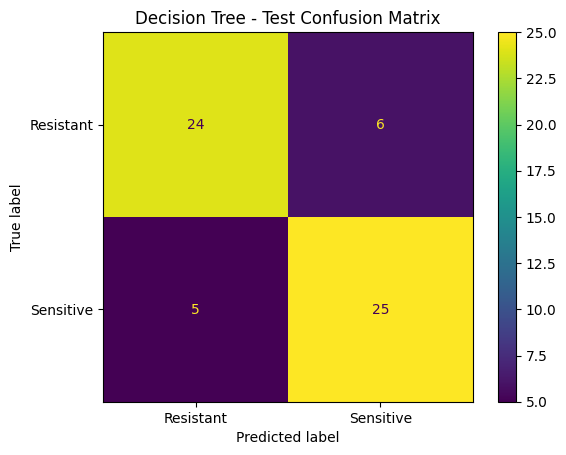

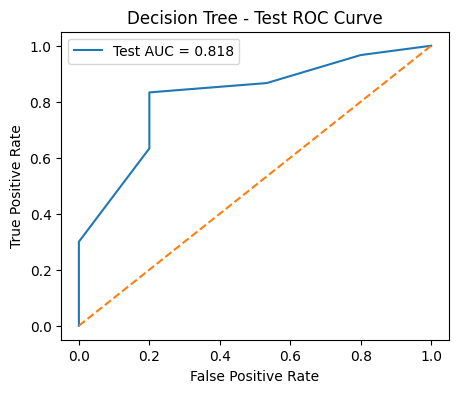

In [ ]:

tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree = evaluate_model(
    "Decision Tree",
    tree,
    X_train, X_test, y_train, y_test
)


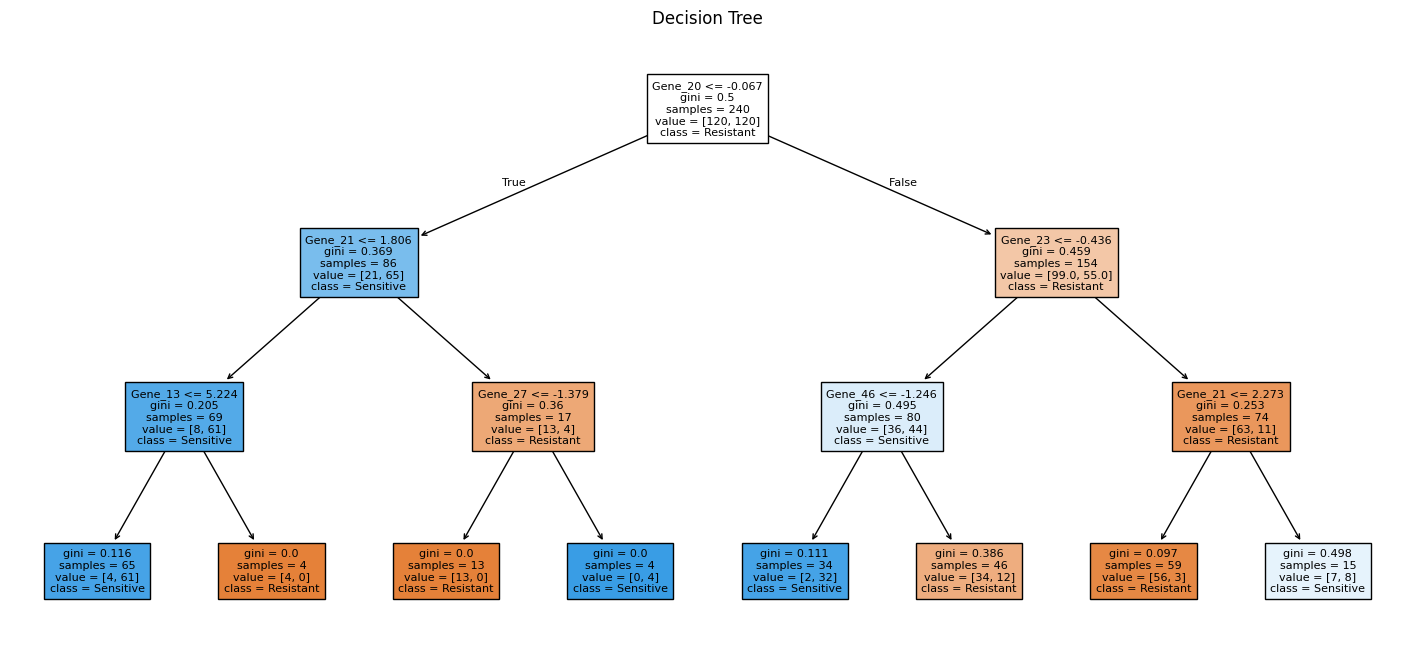

In [ ]:

# Show the first few levels of the tree

plt.figure(figsize=(18,8))
plot_tree(
    tree,
    max_depth=3,
    feature_names=gene_names,
    class_names=["Resistant", "Sensitive"],
    filled=True,
    fontsize=8
)
plt.title("Decision Tree")
plt.show()



## 5.5 Support Vector Machine (SVM)

### 一句話理解

> 找一條 boundary，讓兩群之間的「安全距離 margin」最大。

`RBF kernel` 可以產生非線性的 decision boundary，
所以比單純 linear model 更能處理複雜關係。


Kernel SVM
Train Accuracy = 0.979
Train AUC      = 0.999

Test Accuracy  = 0.667
Test AUC       = 0.734


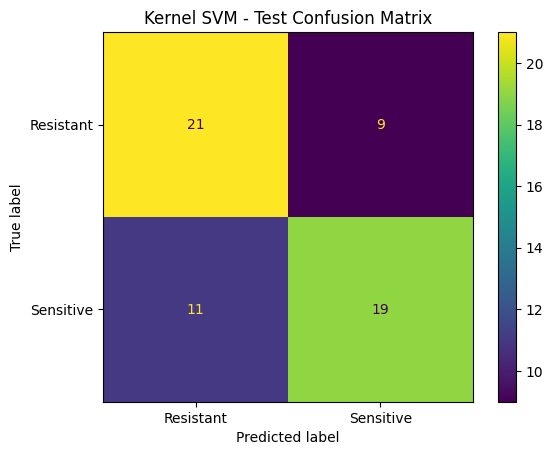

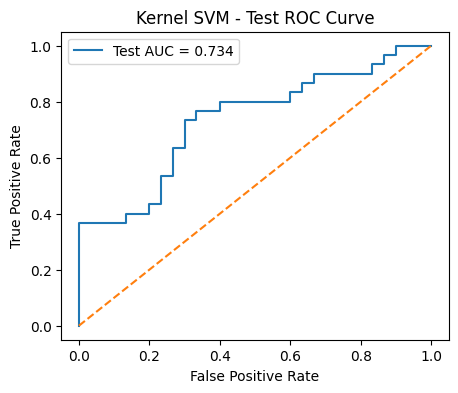

In [ ]:

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])

svm = evaluate_model(
    "Kernel SVM",
    svm,
    X_train, X_test, y_train, y_test
)



## 5.6 Random Forest

### 一句話理解

> 不只問一棵 Decision Tree，而是問很多棵樹，再一起投票。

因此 Random Forest 通常比單棵 Decision Tree 穩定。

它還可以提供：

> **Feature Importance**


Random Forest
Train Accuracy = 0.988
Train AUC      = 1.000

Test Accuracy  = 0.733
Test AUC       = 0.813


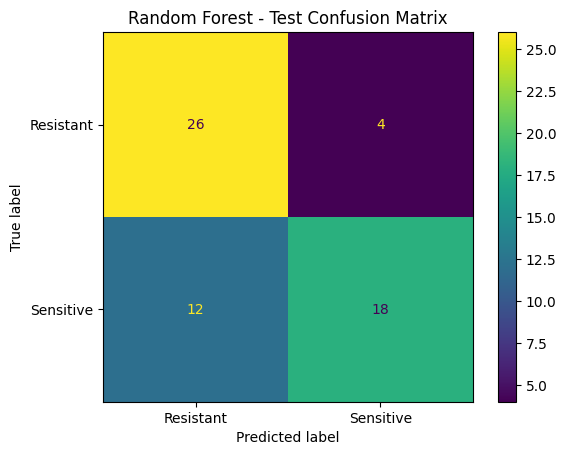

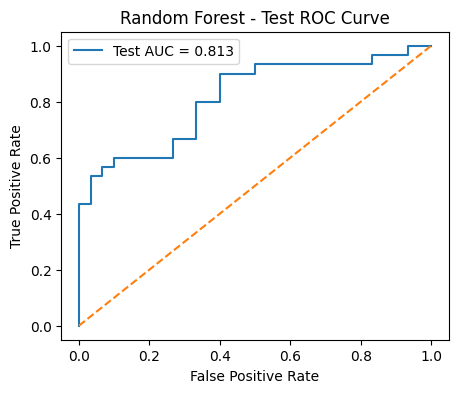

In [ ]:

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42
)

rf = evaluate_model(
    "Random Forest",
    rf,
    X_train, X_test, y_train, y_test
)


       Gene  Importance
22  Gene_23    0.081520
19  Gene_20    0.072822
12  Gene_13    0.058890
6   Gene_07    0.055549
50  Gene_51    0.055452
45  Gene_46    0.054795
26  Gene_27    0.052668
14  Gene_15    0.050468
44  Gene_45    0.039736
20  Gene_21    0.020944


<Figure size 800x500 with 0 Axes>

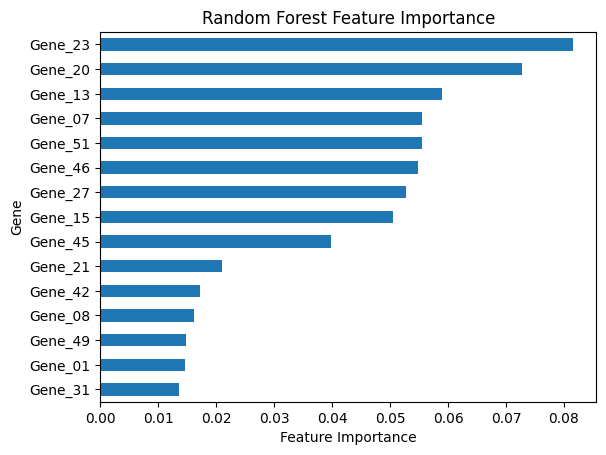

In [ ]:

importance_df = pd.DataFrame({
    "Gene": gene_names,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_df.head(10))

plt.figure(figsize=(8,5))
importance_df.head(15).sort_values("Importance").plot(
    x="Gene", y="Importance", kind="barh", legend=False
)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()



# 6. Compare all Machine Learning models

不要只看單一模型。

我們把所有模型的：

- Accuracy
- ROC-AUC

放在一起比較。


In [ ]:
results_df = pd.DataFrame(
    model_results,
    columns=[
        "Model",
        "Train Accuracy",
        "Train AUC",
        "Test Accuracy",
        "Test AUC"
    ]
).sort_values("Test AUC", ascending=False)

print(results_df)

                 Model  Train Accuracy  Train AUC  Test Accuracy  Test AUC
3        Decision Tree        0.883333   0.934931       0.816667  0.817778
5        Random Forest        0.987500   0.999792       0.733333  0.813333
4           Kernel SVM        0.979167   0.998819       0.666667  0.734444
2                  KNN        0.866667   0.941736       0.633333  0.722778
0  Logistic Regression        0.870833   0.928264       0.700000  0.720000
1                  LDA        0.862500   0.922569       0.666667  0.706667


# 7. Why do we need Feature Selection?

現在使用**相同的 SVM classifier**，只改變輸入的 features，比較 prediction performance。

### Model A
使用全部 **60 genes**

### Model B
只使用前面 **Sequential Forward Selection** 選出的 **10 genes**

這個比較的重點是：

> **Same classifier, different feature sets**

Feature Selection 不一定保證 AUC 一定提高，但如果使用較少 features 仍能維持相近甚至更好的 performance，就代表模型可以更精簡。

In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# ============================================================
# Compare: All Features vs Selected Features using SVM
# ============================================================

# Model 1: 使用全部 60 genes
X_train_all = X_train
X_test_all = X_test
# Model 2: 只使用前面 Sequential Forward Selection 選出的 genes
X_train_selected = X_train[selected_genes]
X_test_selected = X_test[selected_genes]

print("All features:", X_train_all.shape[1])
print("Selected features:", X_train_selected.shape[1])


# -------------------------
# SVM 1: All 60 genes
# -------------------------

svm_all = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])


# -------------------------
# SVM 2: Selected genes
# -------------------------

svm_selected = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])


# Train models
svm_all.fit(
    X_train_all,
    y_train
)

svm_selected.fit(
    X_train_selected,
    y_train
)


# Prediction probability
prob_all = svm_all.predict_proba(
    X_test_all
)[:, 1]

prob_selected = svm_selected.predict_proba(
    X_test_selected
)[:, 1]


# Calculate AUC
auc_all = roc_auc_score(
    y_test,
    prob_all
)

auc_selected = roc_auc_score(
    y_test,
    prob_selected
)


print(f"All 60 genes AUC       : {auc_all:.3f}")
print(f"Selected genes AUC     : {auc_selected:.3f}")

All features: 60
Selected features: 10
All 60 genes AUC       : 0.734
Selected genes AUC     : 0.766


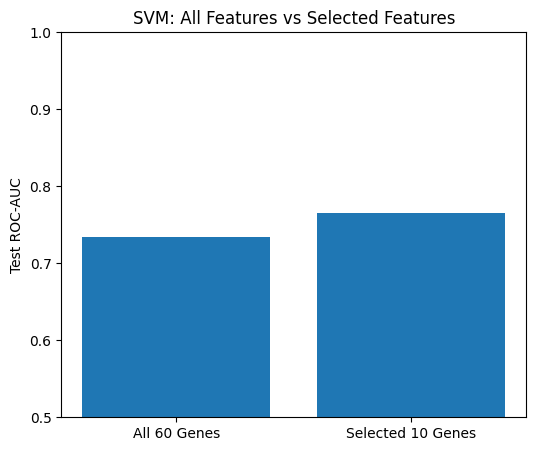

In [ ]:
plt.figure(figsize=(6, 5))

plt.bar(
    [
        "All 60 Genes",
        f"Selected {len(selected_genes)} Genes"
    ],
    [
        auc_all,
        auc_selected
    ]
)

plt.ylim(0.5, 1.0)

plt.ylabel("Test ROC-AUC")
plt.title("SVM: All Features vs Selected Features")

plt.show()


# 8. Deep Learning — Neural Network

Machine Learning 常常需要先定義 features。

Deep Learning 的特色是：

> **透過多層 neural network 學習複雜的 nonlinear representation。**

這裡使用簡單的 Multi-Layer Perceptron（MLP）：

```text
60 genes
   ↓
32 neurons
   ↓
16 neurons
   ↓
Drug response
```




Neural Network (MLP)
Train Accuracy = 0.533
Train AUC      = 0.574

Test Accuracy  = 0.400
Test AUC       = 0.389


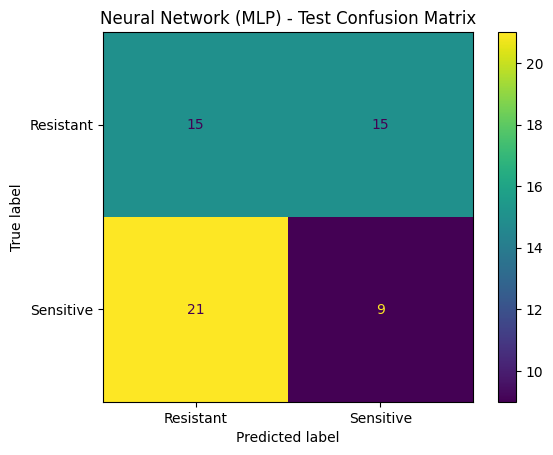

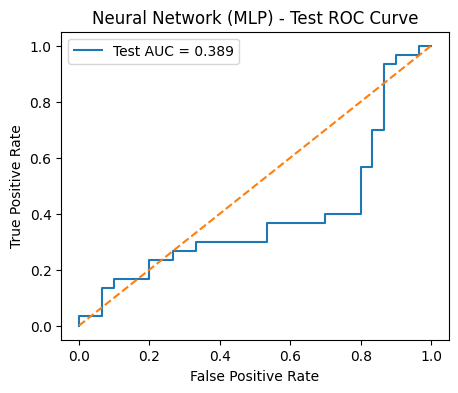

In [ ]:

mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(32,16),
        activation="relu",
        max_iter=1000,
        early_stopping=True,
        random_state=42
    ))
])

mlp = evaluate_model(
    "Neural Network (MLP)",
    mlp,
    X_train, X_test, y_train, y_test
)


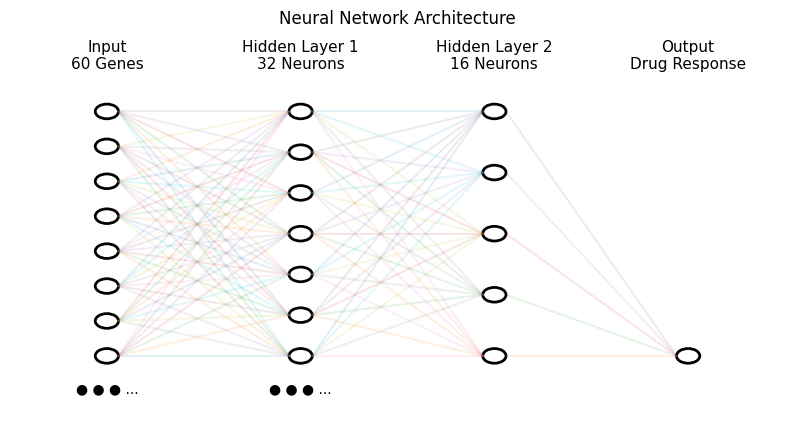

In [ ]:
import matplotlib.pyplot as plt

layers = [60, 32, 16, 1]
layer_names = [
    "Input\n60 Genes",
    "Hidden Layer 1\n32 Neurons",
    "Hidden Layer 2\n16 Neurons",
    "Output\nDrug Response"
]

x = [0, 2, 4, 6]

plt.figure(figsize=(10, 5))

# 教學用：每層只畫少量 neuron，避免真的畫 60 顆
display_neurons = [8, 7, 5, 1]

positions = []

for layer_x, n in zip(x, display_neurons):

    ys = np.linspace(-2, 2, n)
    positions.append(ys)

    for y_pos in ys:
        circle = plt.Circle(
            (layer_x, y_pos),
            0.12,
            fill=False,
            linewidth=2
        )
        plt.gca().add_patch(circle)

# 畫 layer 之間的 connections
for i in range(len(x)-1):

    for y1 in positions[i]:
        for y2 in positions[i+1]:

            plt.plot(
                [x[i]+0.12, x[i+1]-0.12],
                [y1, y2],
                alpha=0.12
            )

# Layer names
for layer_x, name in zip(x, layer_names):

    plt.text(
        layer_x,
        2.7,
        name,
        ha="center",
        fontsize=11
    )

plt.text(0, -2.6, "● ● ● ...", ha="center")
plt.text(2, -2.6, "● ● ● ...", ha="center")

plt.xlim(-1, 7)
plt.ylim(-3, 3.3)
plt.axis("off")

plt.title("Neural Network Architecture")
plt.show()


# 10. Autoencoder — the idea

Autoencoder 的目的不是直接分類，而是：

> **把高維資料壓縮成低維 representation，再重建原始資料。**

概念：

```text
60 genes
   ↓
Encoder
   ↓
Latent representation
   ↓
Decoder
   ↓
Reconstructed 60 genes
```

```text
60 dimensions → 5 latent dimensions → reconstruct
```


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Standardize gene expression
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print("Input data shape:", X_std.shape)

Input data shape: (300, 60)


In [ ]:
# ============================================================
# Build Autoencoder
# ============================================================

# Input: 60 genes
input_layer = Input(shape=(60,))

# Encoder
encoded = Dense(32, activation="relu")(input_layer)
encoded = Dense(16, activation="relu")(encoded)

# Latent representation: compress 60 genes → 5 features
latent = Dense(5, activation="relu", name="Latent_Space")(encoded)

# Decoder
decoded = Dense(16, activation="relu")(latent)
decoded = Dense(32, activation="relu")(decoded)

# Output: reconstruct 60 genes
output_layer = Dense(60)(decoded)

# Autoencoder
autoencoder = Model(
    inputs=input_layer,
    outputs=output_layer
)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_Space (Dense)            │ (None, 5)              │            85 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 60)             │         1,980 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,185 (20.25 KB)

 Trainable params: 5,185 (20.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    X_std,       # Input
    X_std,       # Output 也是自己
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

print("Autoencoder training completed!")

Autoencoder training completed!


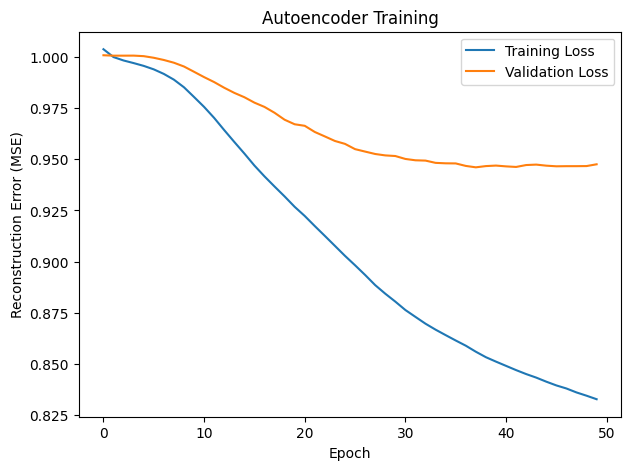

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Error (MSE)")
plt.title("Autoencoder Training")

plt.legend()
plt.show()

In [ ]:
encoder = Model(
    inputs=input_layer,
    outputs=latent
)

X_latent = encoder.predict(
    X_std,
    verbose=0
)

print("Original dimension :", X_std.shape)
print("Latent dimension   :", X_latent.shape)

Original dimension : (300, 60)
Latent dimension   : (300, 5)


In [ ]:
X_reconstructed = autoencoder.predict(
    X_std,
    verbose=0
)

reconstruction_error = np.mean(
    (X_std - X_reconstructed) ** 2
)

print(
    "Reconstruction MSE:",
    round(reconstruction_error, 3)
)

Reconstruction MSE: 0.854


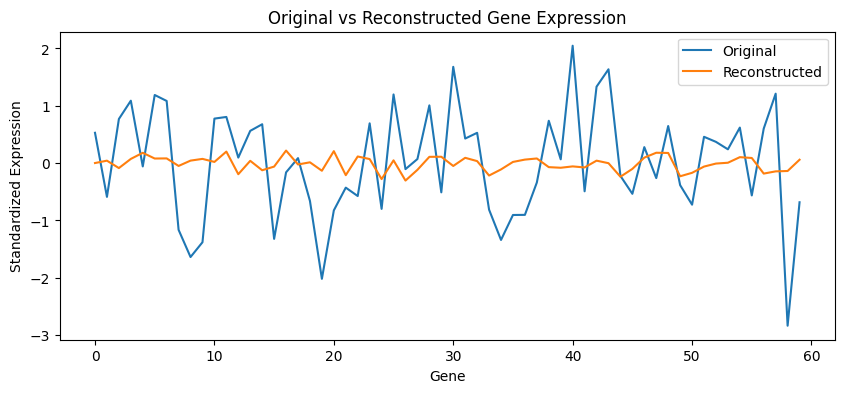

In [ ]:
sample = 0

plt.figure(figsize=(10, 4))

plt.plot(
    X_std[sample],
    label="Original"
)

plt.plot(
    X_reconstructed[sample],
    label="Reconstructed"
)

plt.xlabel("Gene")
plt.ylabel("Standardized Expression")
plt.title("Original vs Reconstructed Gene Expression")

plt.legend()
plt.show()


# 11. Multi-omics Integration

現在模擬三種 omics：

- Gene Expression
- DNA Methylation
- Proteomics

不同 omics 提供互補資訊。

我們示範兩個最重要的方法：

### Early Fusion
先把所有 omics features 接在一起，再訓練一個模型。

### Late Fusion
每個 omics 各自訓練模型，最後再平均 prediction probability。


In [ ]:

# ============================================================
# Simulate multi-omics data
# ============================================================

rng = np.random.default_rng(42)
n = 350

# hidden biological signal
biology = rng.normal(size=n)

# Each omics captures part of the same biological state
rna = np.column_stack([
    biology + rng.normal(scale=0.8, size=n),
    0.7*biology + rng.normal(size=n),
    rng.normal(size=(n, 18))
])

meth = np.column_stack([
    -0.8*biology + rng.normal(scale=0.9, size=n),
    rng.normal(size=(n, 14))
])

protein = np.column_stack([
    1.1*biology + rng.normal(scale=0.7, size=n),
    rng.normal(size=(n, 9))
])

# drug response depends on hidden biology + noise
response_score = biology + rng.normal(scale=0.9, size=n)
y_multi = (response_score > np.median(response_score)).astype(int)

print("RNA shape      :", rna.shape)
print("Methylation    :", meth.shape)
print("Proteomics     :", protein.shape)


RNA shape      : (350, 20)
Methylation    : (350, 15)
Proteomics     : (350, 10)


In [ ]:

idx_train, idx_test = train_test_split(
    np.arange(n),
    test_size=0.25,
    stratify=y_multi,
    random_state=42
)

def fit_prob(X_data):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ])
    model.fit(X_data[idx_train], y_multi[idx_train])
    prob = model.predict_proba(X_data[idx_test])[:,1]
    auc = roc_auc_score(y_multi[idx_test], prob)
    return model, prob, auc

# Single omics
rna_model, rna_prob, rna_auc = fit_prob(rna)
meth_model, meth_prob, meth_auc = fit_prob(meth)
protein_model, protein_prob, protein_auc = fit_prob(protein)

print("RNA-only AUC        :", round(rna_auc, 3))
print("Methylation-only AUC:", round(meth_auc, 3))
print("Proteomics-only AUC :", round(protein_auc, 3))


RNA-only AUC        : 0.748
Methylation-only AUC: 0.76
Proteomics-only AUC : 0.851



## 11.1 Early Fusion

直接做：

```text
RNA    ─┐
Meth    ├── Concatenate → One model → Prediction
Protein ┘
```


In [ ]:

early_X = np.concatenate([rna, meth, protein], axis=1)

early_model, early_prob, early_auc = fit_prob(early_X)

print("Early Fusion AUC:", round(early_auc, 3))


Early Fusion AUC: 0.82



## 11.2 Late Fusion

先分開預測：

```text
RNA → Model ──────────┐
Meth → Model ─────────┼→ Average probability → Prediction
Protein → Model ──────┘
```


In [ ]:

late_prob = (rna_prob + meth_prob + protein_prob) / 3
late_auc = roc_auc_score(y_multi[idx_test], late_prob)

print("Late Fusion AUC:", round(late_auc, 3))


Late Fusion AUC: 0.854


             Method       AUC
4       Late Fusion  0.853822
2   Proteomics only  0.851240
3      Early Fusion  0.819731
1  Methylation only  0.759814
0          RNA only  0.748450


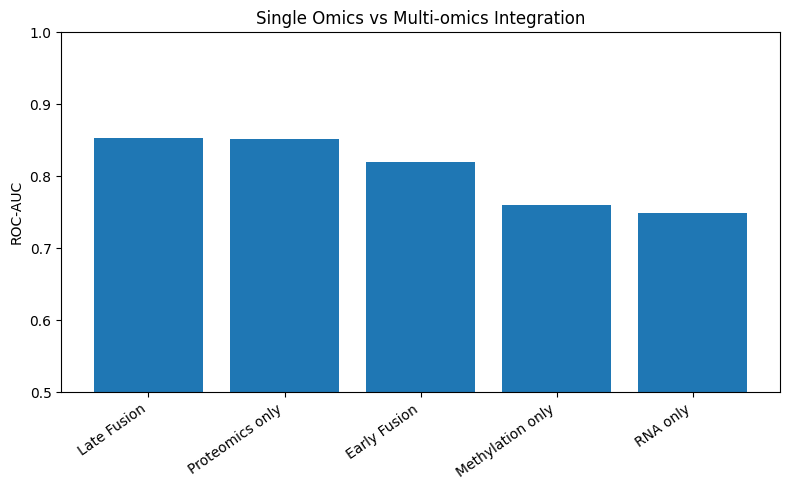

In [ ]:

fusion_results = pd.DataFrame({
    "Method": [
        "RNA only",
        "Methylation only",
        "Proteomics only",
        "Early Fusion",
        "Late Fusion"
    ],
    "AUC": [
        rna_auc,
        meth_auc,
        protein_auc,
        early_auc,
        late_auc
    ]
}).sort_values("AUC", ascending=False)

print(fusion_results)

plt.figure(figsize=(8,5))
plt.bar(fusion_results["Method"], fusion_results["AUC"])
plt.ylim(0.5,1.0)
plt.ylabel("ROC-AUC")
plt.title("Single Omics vs Multi-omics Integration")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()



# 11. Visualizing the data with PCA

60 維的 gene expression 人眼看不到。

PCA 可以把資料壓到 2D，
讓我們看大概的資料結構。

> PCA 主要是 visualization / dimensionality reduction，
> 不代表它一定是最好的 biomarker selection。

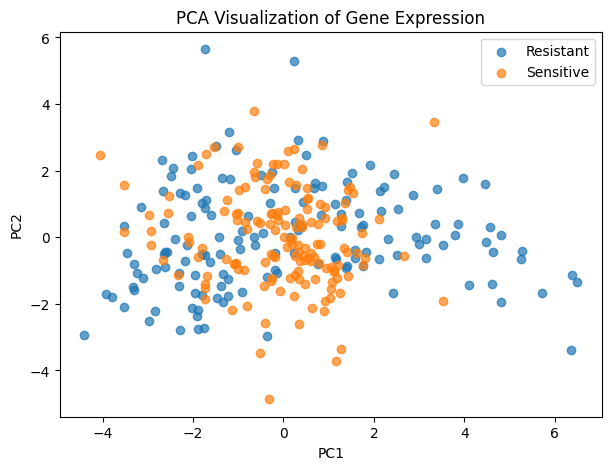

Variance explained by PC1 + PC2: 0.105


In [ ]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))

for cls, label in [(0, "Resistant"), (1, "Sensitive")]:
    mask = (y.values == cls)
    plt.scatter(
        X_pca[mask,0],
        X_pca[mask,1],
        alpha=0.7,
        label=label
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization of Gene Expression")
plt.legend()
plt.show()

print(
    "Variance explained by PC1 + PC2:",
    round(pca.explained_variance_ratio_.sum(), 3)
)



# 12. Domain Shift: Cell Line → Patient

最後示範簡報裡很重要的問題：

> 在 cell line 訓練的 model，到了 patient 不一定表現一樣。

因為兩個 domain 的資料分布可能不同。

我們故意把 patient data 做一個 shift，
模擬 **domain gap**。


In [ ]:
# =========================
# 1. Simulate Cell Line Data
# =========================

X_source, y_source = make_classification(
    n_samples=500,
    n_features=20,
    n_informative=6,
    class_sep=1.5,
    random_state=7
)

In [ ]:
# =========================
# 2. Simulate Patient Data
# =========================

rng = np.random.default_rng(7)

# 先保留相同的 biological structure
X_target = X_source[:180].copy()
y_target = y_source[:180].copy()

# 加入 distribution shift，模擬 Cell Line 與 Patient 的 domain gap
shift = np.linspace(-1.5, 1.5, X_target.shape[1])

X_target = X_target * 1.2 + shift + rng.normal(
    scale=0.35,
    size=X_target.shape
)

print("Cell Line data shape:", X_source.shape)
print("Patient data shape  :", X_target.shape)

Cell Line data shape: (500, 20)
Patient data shape  : (180, 20)


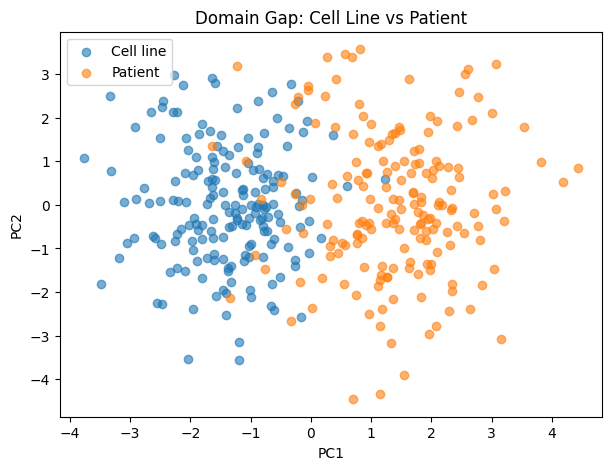

In [ ]:

# PCA view of domain shift

combined = np.vstack([X_source[:180], X_target])
domain = np.array(["Cell line"]*180 + ["Patient"]*180)

combined_scaled = StandardScaler().fit_transform(combined)
coords = PCA(n_components=2).fit_transform(combined_scaled)

plt.figure(figsize=(7,5))

for d in ["Cell line", "Patient"]:
    mask = domain == d
    plt.scatter(
        coords[mask,0],
        coords[mask,1],
        alpha=0.6,
        label=d
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Domain Gap: Cell Line vs Patient")
plt.legend()
plt.show()


In [ ]:
# =========================
# 3. Train Model using Cell Line Data
# =========================

source_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

# 只使用 Cell Line data 建模
source_model.fit(
    X_source,
    y_source
)

print("Model trained using Cell Line data.")

Model trained using Cell Line data.


In [ ]:
# =========================
# 4. Predict Cell Line and Patient
# =========================

# 同一個已訓練好的模型
source_prob = source_model.predict_proba(
    X_source
)[:, 1]

target_prob = source_model.predict_proba(
    X_target
)[:, 1]

# Evaluate performance
source_auc = roc_auc_score(
    y_source,
    source_prob
)

target_auc = roc_auc_score(
    y_target,
    target_prob
)

print("Cell Line AUC:", round(source_auc, 3))
print("Patient AUC  :", round(target_auc, 3))

Cell Line AUC: 0.731
Patient AUC  : 0.716



# 14. Optional classroom exercise

嘗試改下面幾個參數，看圖和 AUC 怎麼變：

1. KNN 的 `n_neighbors=3 / 5 / 15`
2. Decision Tree 的 `max_depth=2 / 4 / None`
3. Random Forest 的 `n_estimators=10 / 100 / 500`
4. SVM 的 `kernel="linear"` vs `"rbf"`
5. Feature Selection 使用 Top 5 / Top 10 / Top 20 genes
6. Neural Network hidden layers 改成 `(8,)`、`(32,16)`、`(64,32,16)`

